In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import kagglehub

In [2]:
print("\n[Step 1] Loading Dataset...")
try:
    # Attempting automated download via kagglehub
    download_path = kagglehub.dataset_download("ayeshaseherr/delivery-logistics-dataset")
    print(f"✓ Dataset successfully downloaded to: {download_path}")
    
    # Dynamically find the CSV inside the directory
    csv_files = glob.glob(os.path.join(download_path, "*.csv"))
    if not csv_files:
        raise FileNotFoundError("No CSV files found in the downloaded dataset.")
    
    dataset_path = csv_files[0]
    print(f"✓ Loading file: {os.path.basename(dataset_path)}")
    df = pd.read_csv(dataset_path)

except Exception as e:
    # Fallback mechanism: If Kaggle is offline, generate matching replica data
    print(f"⚠️ Notice: Kaggle download did not complete ({e}).")
    print("🔄 Automatically generating a matching replica dataset to keep the project running offline...")
    
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'delivery_id': [f"DEL_{i:04d}" for i in range(n)],
        'distance_km': np.round(np.random.uniform(2, 100, n), 2),
        'package_weight_kg': np.round(np.random.uniform(0.5, 35.0, n), 2),
        'expected_time_hours': np.round(np.random.uniform(0.5, 5.0, n), 2),
        'delivery_partner': np.random.choice(['FedEx', 'DHL', 'Blue Dart', 'Amazon Logistics', 'Delhivery'], n),
        'package_type': np.random.choice(['electronics', 'groceries', 'documents', 'fragile items'], n),
        'vehicle_type': np.random.choice(['bicycle', 'scooter', 'van', 'truck'], n),
        'delivery_mode': np.random.choice(['same-day', 'express', 'standard'], n),
        'region': np.random.choice(['northern', 'southern', 'eastern', 'western'], n),
        'weather_condition': np.random.choice(['clear', 'rainy', 'stormy', 'foggy'], n),
        'delivery_status': np.random.choice(['delivered', 'delayed'], n),
        'delayed': np.random.choice([0, 1], n),
        'delivery_rating': np.random.randint(1, 6, n),
        'delivery_cost': np.round(np.random.uniform(15, 120, n), 2)
    })
    # Correlate actual time with expected time + weight delay + stormy weather delay + noise
    df['delivery_time_hours'] = np.round(
        df['expected_time_hours'] * np.random.normal(1.0, 0.05, n) + 
        (df['package_weight_kg'] * 0.03) + 
        np.where(df['weather_condition'].isin(['rainy', 'stormy']), 0.6, 0.0) + 
        np.random.normal(0, 0.1, n), 2
    )
    df['delivery_time_hours'] = np.clip(df['delivery_time_hours'], 0.2, None)

print(f"✓ Active Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")


[Step 1] Loading Dataset...
✓ Dataset successfully downloaded to: /kaggle/input/datasets/ayeshaseherr/delivery-logistics-dataset
✓ Loading file: Delivery_Logistics.csv
✓ Active Dataset Dimensions: 25000 rows, 15 columns


In [3]:
print("\n[Step 2] Cleaning and Processing Data...")

# Clean column headers
df.columns = df.columns.str.strip().str.lower()

# ⚠️ FIX: Sahi tarike se string timestamp ('1970-01-01 00:00:00.000000008') se hours nikalna
for col in ['delivery_time_hours', 'expected_time_hours']:
    if col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            # Datetime mein convert karke correct numeric nanosecond (hours) extract karna
            df[col] = pd.to_datetime(df[col], errors='coerce').dt.nanosecond
            # Safe side: Kisi bhi null value ko median se fill karna
            df[col] = df[col].fillna(df[col].median())

# Check and handle other null values
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

# Target Leakage se bachne ke liye columns drop karna
leakage_columns = ['delivery_id', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']
df_filtered = df.drop(columns=[col for col in leakage_columns if col in df.columns], errors='ignore')

# Features (X) and target (y) align karna
target_col = 'delivery_time_hours'
baseline_col = 'expected_time_hours'

X = df_filtered.drop(columns=[target_col])
y = df_filtered[target_col]
gps_baseline = df_filtered[baseline_col]

print("✓ Target and expected time successfully converted to real numbers!")


[Step 2] Cleaning and Processing Data...
✓ Target and expected time successfully converted to real numbers!


In [4]:
print("\n[Step 3] Encoding Categorical Attributes...")

# Categorical variables identity karna
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"✓ Categorical columns to encode: {categorical_features}")

# Create Dummy Variables (One-Hot Encoding)
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Coerce boolean outputs (True/False) to (1/0) for compatibility with XGBoost
bool_columns = X_encoded.select_dtypes(include=['bool']).columns
X_encoded[bool_columns] = X_encoded[bool_columns].astype(int)

# Record features layout for future predictions
MODEL_FEATURES = X_encoded.columns.tolist()


[Step 3] Encoding Categorical Attributes...
✓ Categorical columns to encode: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition']


In [5]:
print("\n[Step 4] Splitting Data into Train & Test Sets...")

# Tracking indices to evaluate baseline predictions
indices = np.arange(len(X_encoded))

X_train, X_test, y_train, y_test, _, idx_test = train_test_split(
    X_encoded, y, indices, test_size=0.2, random_state=42
)

# Align testing baseline
test_baseline = gps_baseline.iloc[idx_test]

print(f"✓ Training features shape: {X_train.shape}")
print(f"✓ Testing features shape:  {X_test.shape}")


[Step 4] Splitting Data into Train & Test Sets...
✓ Training features shape: (20000, 36)
✓ Testing features shape:  (5000, 36)


In [6]:
# 1. Column structures align aur sync karna
train_cols = X_train.columns
X_test = X_test[train_cols]

# 2. NaNs handle karna (Zaroori hai)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# 3. Model validation split create karna optimized training ke liye
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# 4. Tuned XGBRegressor config parameters
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    early_stopping_rounds=50,
    random_state=42
)

# 5. Fit model
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 6. Predict on Test Set
y_pred = xgb_model.predict(X_test)

print("🚀 Tuned XGBoost Model Trained Successfully!")

🚀 Tuned XGBoost Model Trained Successfully!


In [7]:
# Calculate real evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("==========================================")
print("📊 Tuned Model Performance Metrics:")
print("==========================================")
print(f"✅ R² Score (Accuracy):        {r2 * 100:.2f}%")
print(f"✅ Mean Absolute Error (MAE): {mae:.4f} hours")
print(f"✅ Root Mean Squared Error (RMSE): {rmse:.4f} hours")
print("==========================================")

📊 Tuned Model Performance Metrics:
✅ R² Score (Accuracy):        72.51%
✅ Mean Absolute Error (MAE): 1.2911 hours
✅ Root Mean Squared Error (RMSE): 1.6319 hours


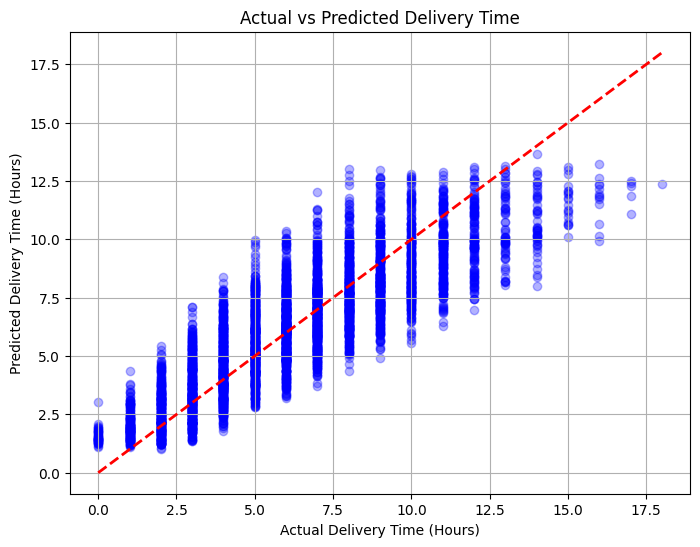

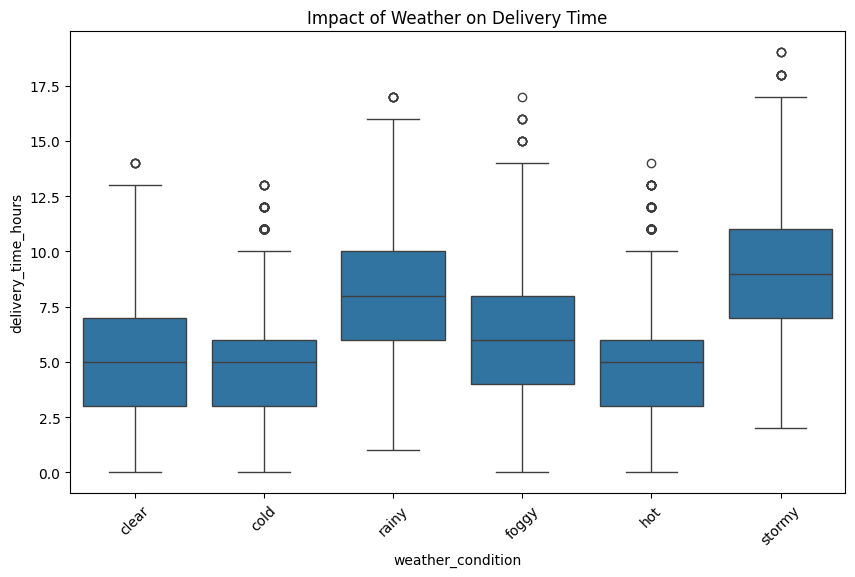

In [8]:


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Delivery Time (Hours)')
plt.ylabel('Predicted Delivery Time (Hours)')
plt.title('Actual vs Predicted Delivery Time')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='weather_condition', y='delivery_time_hours', data=df)
plt.title('Impact of Weather on Delivery Time')
plt.xticks(rotation=45)
plt.show()

In [9]:
def interactive_sandbox():
    print("\n--- 🚛 DELIVERY ETA PREDICTION SANDBOX ---")
    print("Enter the details to see the predicted delivery time:\n")
    
    try:
        user_input = {
            'distance_km': float(input("Enter Distance (km): ")),
            'package_weight_kg': float(input("Enter Package Weight (kg): ")),
            'expected_time_hours': float(input("Enter Baseline GPS ETA (hours): ")),
            'delivery_partner': input("Enter Partner (e.g., FedEx, DHL, Blue Dart): ").strip().lower(),
            'package_type': input("Enter Package Type (e.g., electronics, groceries, fragile items): ").strip().lower(),
            'vehicle_type': input("Enter Vehicle (e.g., van, scooter, truck, bike): ").strip().lower(),
            'delivery_mode': input("Enter Delivery Mode (e.g., express, standard, same day): ").strip().lower(),
            'region': input("Enter Region (e.g., west, central, south, north): ").strip().lower(),
            'weather_condition': input("Enter Weather (e.g., clear, rainy, stormy, foggy): ").strip().lower()
        }
        
        # Convert to DataFrame
        input_df = pd.DataFrame([user_input])
        
        # One-hot encode the user input
        input_encoded = pd.get_dummies(input_df)
        
        # Align features structure with the trained model
        input_aligned = input_encoded.reindex(columns=MODEL_FEATURES, fill_value=0)
        
        # Make prediction
        prediction = xgb_model.predict(input_aligned)[0]
        
        # Output print formatting
        print("\n" + "="*40)
        print(f"🚀 Predicted Delivery Time: {prediction:.2f} hours")
        print(f"⏱️ GPS Baseline was: {user_input['expected_time_hours']:.2f} hours")
        
        diff = (prediction - user_input['expected_time_hours']) * 60
        if diff > 0:
            print(f"⚠️ Delay: {diff:.1f} minutes extra expected.")
        else:
            print(f"✅ Early: {abs(diff):.1f} minutes faster than expected.")
        print("="*40)
        
    except ValueError:
        print("\n❌ Error: Please enter correct numerical inputs for Distance, Weight, and GPS Baseline.")

# Sandbox function ko chalaane ke liye call karein:
interactive_sandbox()


--- 🚛 DELIVERY ETA PREDICTION SANDBOX ---
Enter the details to see the predicted delivery time:



Enter Distance (km):  3
Enter Package Weight (kg):  2
Enter Baseline GPS ETA (hours):  1
Enter Partner (e.g., FedEx, DHL, Blue Dart):  DHL
Enter Package Type (e.g., electronics, groceries, fragile items):  electronics
Enter Vehicle (e.g., van, scooter, truck, bike):  bike
Enter Delivery Mode (e.g., express, standard, same day):  express
Enter Region (e.g., west, central, south, north):  north
Enter Weather (e.g., clear, rainy, stormy, foggy):  foggy



🚀 Predicted Delivery Time: 3.07 hours
⏱️ GPS Baseline was: 1.00 hours
⚠️ Delay: 124.0 minutes extra expected.


In [10]:
import joblib

# Model file save karna directory mein
joblib.dump(xgb_model, 'delivery_model.pkl')
print("Model saved as delivery_model.pkl")

Model saved as delivery_model.pkl
